<a href="https://colab.research.google.com/github/Rohan-cherkar/DS-with-Python/blob/init/Experiment_04_Ploting2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment No : 04

##**Aim :**
Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

## Performance :

[Students need to execute each and every cell in this section and note the output of the same. Once done they have to answer Questions mentioned in review section]


### Density and Contour plots
Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: ``plt.contour`` for contour plots, ``plt.contourf`` for filled contour plots, and ``plt.imshow`` for showing images.

We will see examples of this type of plot in section below

In [4]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set the seaborn style before importing pyplot
sns.set_theme(style="whitegrid")

In [5]:
# A 3D function to plot

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the ``plt.contour`` function.
It takes three arguments: a grid of *x* values, a grid of *y* values, and a grid of *z* values.

The *x* and *y* values represent positions on the plot, and the *z* values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the ``np.meshgrid`` function, which builds two-dimensional grids from one-dimensional arrays:

In [6]:
# x is set of 50 values between 0 and 5
# x is set of 40 values between 0 and 5

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

Now let's look at this with a standard line-only contour plot:

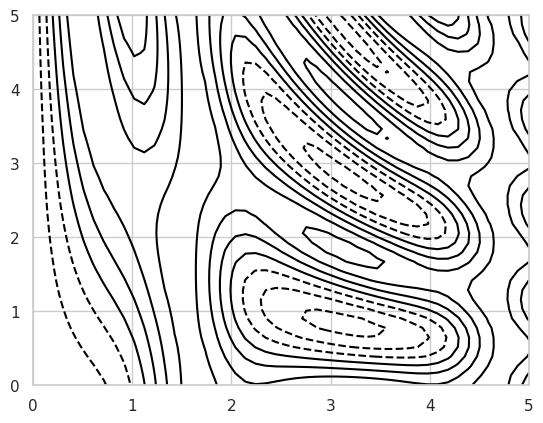

In [7]:
plt.contour(X, Y, Z, colors='black');

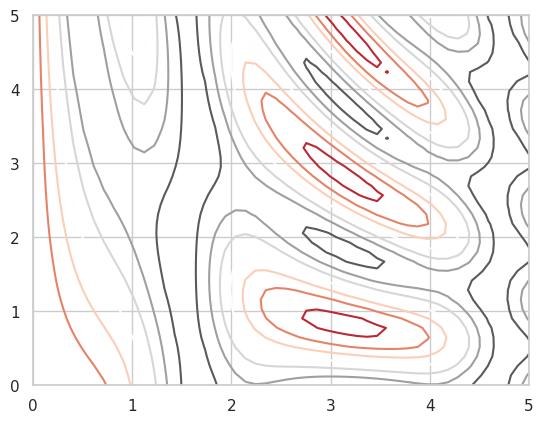

In [8]:
plt.contour(X, Y, Z, cmap='RdGy');

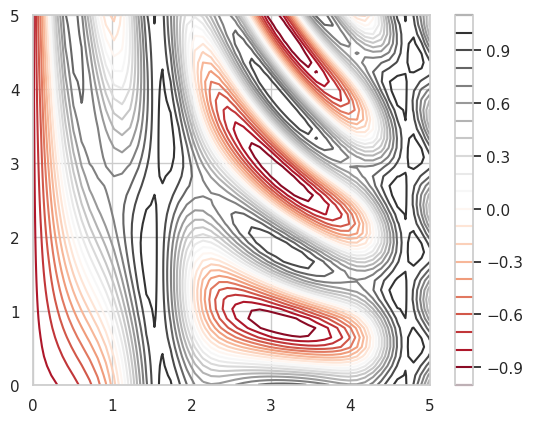

In [9]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

Answer Following Questions :
1.   Explain what are the changes you observe in contour plots above 3 code cells ?
2.   What is size of X, Y and Z  respectively ?
3.   How does colorbar() method help in contour plot.

<b>Q1.Explain what are the changes you observe in contour plots above 3 code cells ?</b>
<br>
1.In the first contour plots the contour are colored with black lines as we have mentioned color ="black"<br>
2.In second contour graph there This uses the 'RdGy' colormap (Red-Grey color scheme).The contour lines are colored according to the Z values using this colormap.<br>
3.in the 3rd plt.contour(X, Y, Z, cmap='RdGy') (Yes, it's a repeat).This is exactly the same as the second one.


<b>Q2.What is size of X, Y and Z respectively ?</b>

X	(40, 50)
Y	(40, 50)
Z	(40, 50)

<b>Q3.How does colorbar() method help in contour plot.</b>
When you plot a contour using a colormap, like:

It draws contour lines where the color of each line represents the Z-value level. But you can't tell which color corresponds to which Z-value just by looking at it.<br>

This adds a color scale (legend) on the side of the plot, showing:
<br>
The range of Z-values in the plot
<br>
The mapping between color and value
(i.e. dark red = high value, gray = low value, etc.)

### Creating Smoother Contour Plots
One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level.
A better way to handle this is to use the ``plt.imshow()`` function, which interprets a two-dimensional grid of data as an image.

The following code shows how to perform this:

(np.float64(0.0), np.float64(5.0), np.float64(0.0), np.float64(5.0))

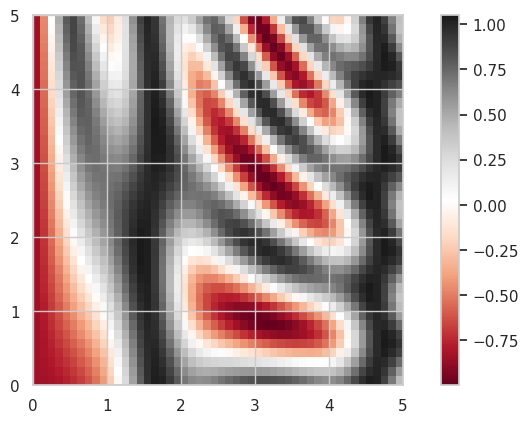

In [11]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
plt.axis('scaled') # Changed line

Things to remember while using ``imshow()``:

- ``plt.imshow()`` doesn't accept an *x* and *y* grid, so you must manually specify the *extent* [*xmin*, *xmax*, *ymin*, *ymax*] of the image on the plot.
- ``plt.imshow()`` by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.
- ``plt.imshow()`` will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, ``plt.axis(aspect='image')`` to make *x* and *y* units match.

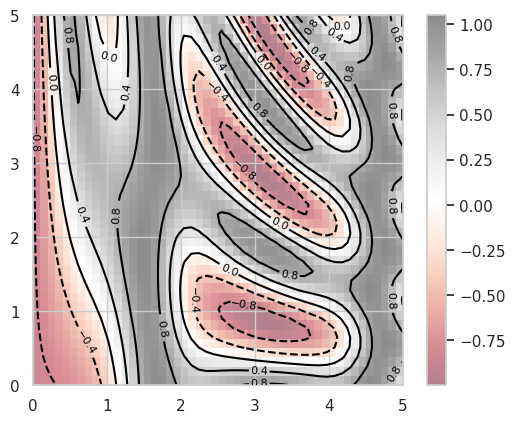

In [12]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

Answer Following Questions :<br>
**1.What does alpha parameter do ?**
<br>
n matplotlib (and many plotting libraries), the alpha parameter controls the transparency (or opacity) of a plot element.

Meaning of alpha:
alpha = 1.0 → Fully opaque (default)

alpha = 0.0 → Fully transparent (invisible)

alpha = 0.5 → 50% transparent

Why use alpha?
To overlay plots (e.g., contour + scatter) without one hiding the other<br>
To create visual layering effects<br>
To de-emphasize certain elements in the plot<br>
To show multiple datasets on the same axes clearly<br>

2.<b>What does clabel method does ?</b><br>
In matplotlib, clabel() is used to add numerical labels to the contour lines in a contour plot.
<br>What it does:
plt.contour(...) returns a QuadContourSet object (contours)

plt.clabel(contours) takes that object and adds labels showing the Z-values directly on the contour lines

So instead of just seeing wavy lines with different colors, you’ll also see values like 0.5, 1.2, -0.3, etc. on the lines themselves.

Why it's useful:
Makes the plot more interpretable
<br>
You can see exact Z-values at specific contour lines
<br>
Especially handy when you don’t want to use or rely solely on a colorbar()
<br>
3.Recreate above code block after, changing parameter 4 in contour fuction to 5 from 3. Explain what change you see in the plot.  

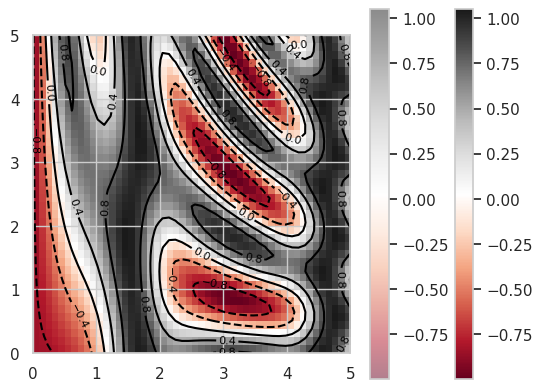

In [13]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy')
plt.colorbar()
plt.axis('scaled')  # Keeps aspect ratio equal

# Changed number of contour levels from 3 to 5
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

# Overlay semi-transparent heatmap
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy', alpha=0.5)
plt.colorbar()


### Histogram, Binning Plots

A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:



*   The data should be numerical.
*   A histogram is used to check the shape of the data distribution.
*   Used to check whether the process changes from one period to another.
*   Used to determine whether the output is different when it involves two or more processes.
*   Used to analyse whether the given process meets the customer requirements.



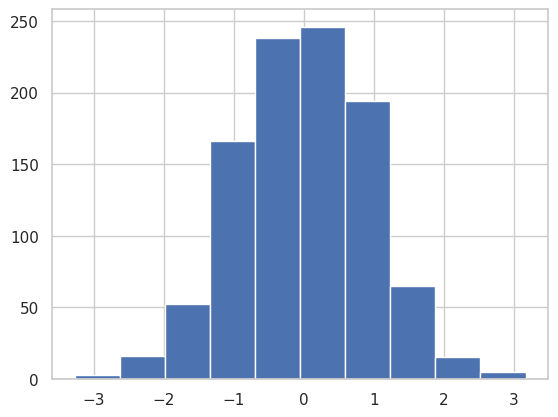

In [14]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);

The ``hist()`` function has many options to tune both the calculation and the display;
here's an example of a more customized histogram:

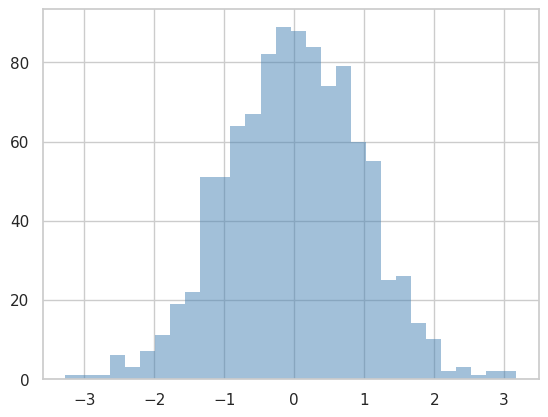

In [15]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The ``plt.hist`` docstring has more information on other customization options available.
I find this combination of ``histtype='stepfilled'`` along with some transparency ``alpha`` to be very useful when comparing histograms of several distributions:

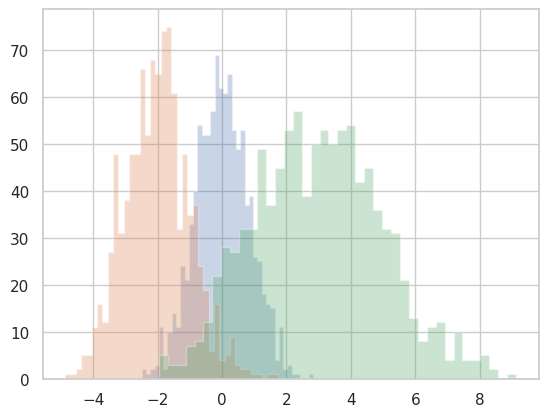

In [16]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the ``np.histogram()`` function is available:

In [17]:
#Only storing histogram bin frequencies without ploting it
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 19 218 484 259  20] [-3.27672869 -1.98739911 -0.69806954  0.59126004  1.88058962  3.1699192 ]


### ``plt.hist2d``: Two-dimensional histogram

One straightforward way to plot a two-dimensional histogram is to use Matplotlib's ``plt.hist2d`` function:

In [18]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

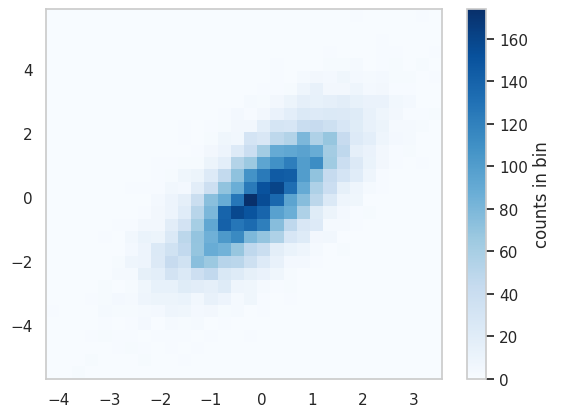

In [19]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with ``plt.hist``, ``plt.hist2d`` has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring.
Further, just as ``plt.hist`` has a counterpart in ``np.histogram``, ``plt.hist2d`` has a counterpart in ``np.histogram2d``, which can be used as follows:

In [20]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

### ``plt.hexbin``: Hexagonal binnings

The two-dimensional histogram creates a tesselation of squares across the axes.
Another natural shape for such a tesselation is the regular hexagon.
For this purpose, Matplotlib provides the ``plt.hexbin`` routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

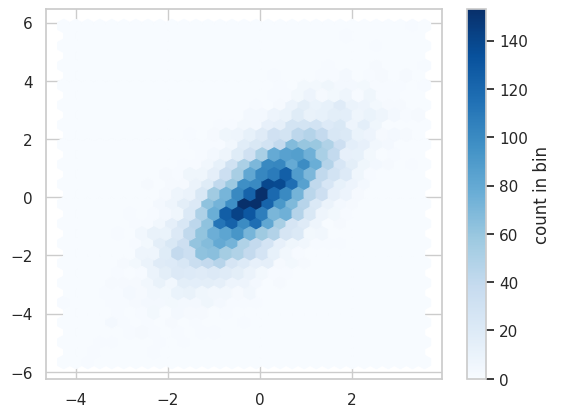

In [21]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

Questions:

1.  What is role of bins parameter in histogram plot?<br>
In a histogram (like plt.hist(data, bins=10)), the bins parameter decides how the range of your data is divided into intervals (called "bins").

Each bin:

Covers a range of values

Counts how many data points fall into that range

Is represented as a bar in the histogram<br>

2.  Create a set of 10000 uniform random samples and store it in variable named *norm_data*. Draw histograms of *norm_data* with following bin counts 5, 50, 500, 5000.


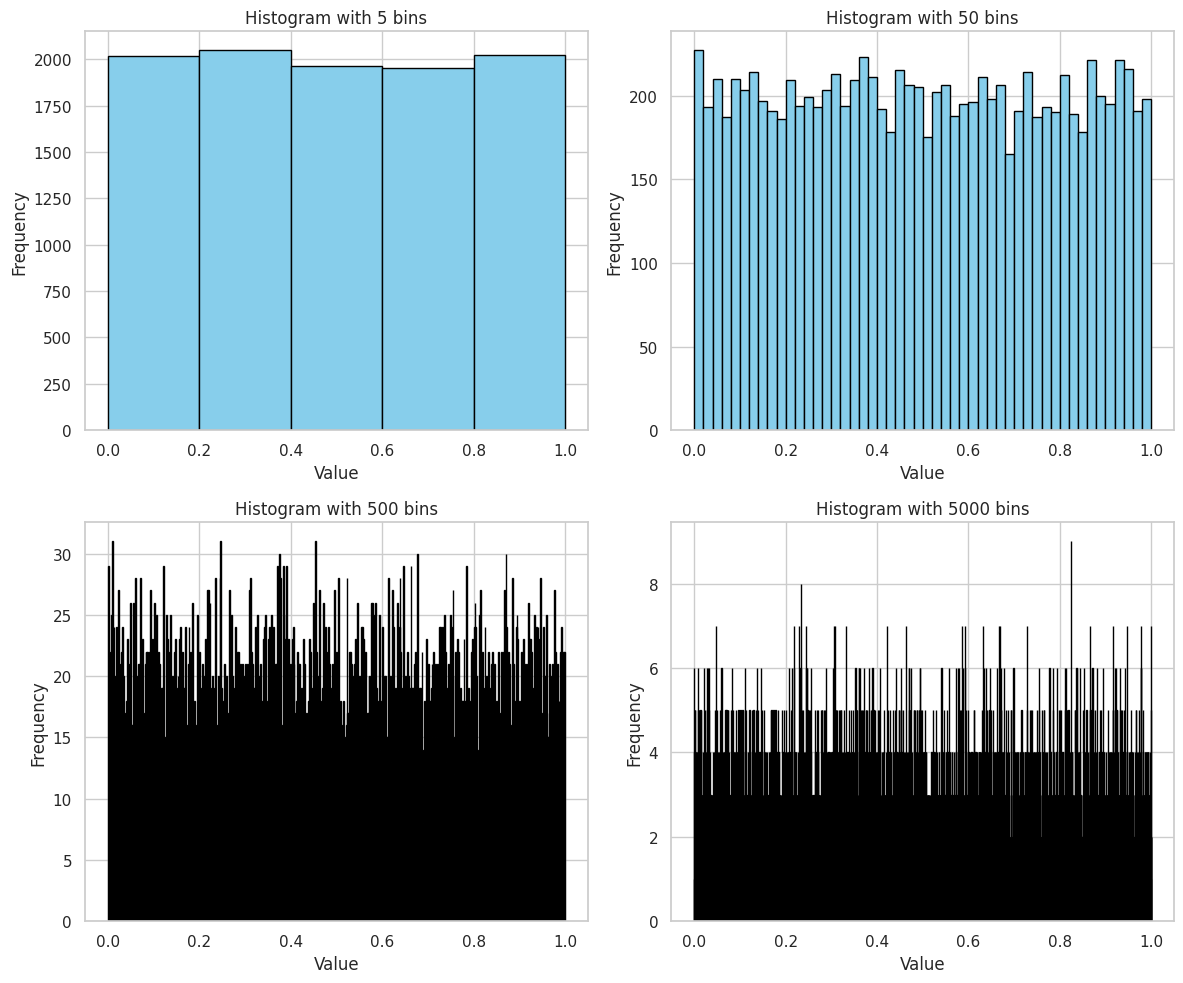

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create uniform random samples
norm_data = np.random.uniform(low=0.0, high=1.0, size=10000)

# Step 2: Plot histograms with different bin sizes
bin_counts = [5, 50, 500, 5000]
plt.figure(figsize=(12, 10))

for i, bins in enumerate(bin_counts, 1):
    plt.subplot(2, 2, i)
    plt.hist(norm_data, bins=bins, color='skyblue', edgecolor='black')
    plt.title(f'Histogram with {bins} bins')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


**Q3.Explain your observations in text box of above step.**

Histogram with 5 bins:
<br>
Provides a very coarse and high-level view of the data.
Large bin widths hide fine details of the uniform distribution.
Useful for a quick summary, but not for analyzing distribution shape.

<br>**Histogram with 50 bins**:

Offers a balanced view with good resolution.

Shows the uniformity of the data more clearly.

Still smooth and easy to interpret.

<br>
**Histogram with 500 bins:**

Provides a high-resolution view, revealing more variation.

Slight randomness/noise appears due to small bin widths.

Good for detailed inspection, but may be harder to read.
<br>

**Histogram with 5000 bins:**

Extremely fine-grained view.

Bars are very thin; many bins may appear empty or noisy.

Can be visually overwhelming and not very informative unless zoomed in.

### Ploting from a CSV File

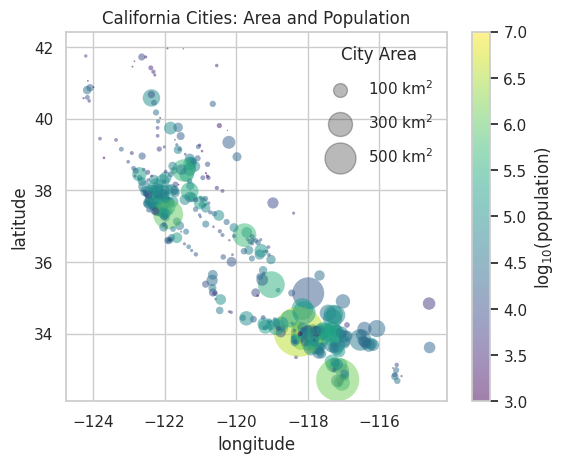

In [28]:
# Path to file /content/drive/MyDrive/AIDS1/notebooks/data/california_cities.csv

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Path to file /content/drive/MyDrive/AIDS1/notebooks/data/california_cities.csv
cities = pd.read_csv('california_cities.csv') #i have saved file in notebook

# Extract the data we're interested in
lat, lon = cities['latd'], cities['longd']
population, area = cities['population_total'], cities['area_total_km2']

# Scatter the points, using size and color but no label
plt.scatter(lon, lat, label=None,
            c=np.log10(population), cmap='viridis',
            s=area, linewidth=0, alpha=0.5)

# Use plt.gca().set_aspect('equal') to set aspect ratio
plt.gca().set_aspect('equal', adjustable='box')  # Ensures equal scaling of x and y axes

plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar(label='log$_{10}$(population)')
plt.clim(3, 7)

# Here we create a legend:
# we'll plot empty lists with the desired size and label
for area in [100, 300, 500]:
    plt.scatter([], [], c='k', alpha=0.3, s=area,
                label=str(area) + ' km$^2$')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title='City Area')

plt.title('California Cities: Area and Population');

### Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of *subplots* : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the seaborn style using sns.set_theme()
sns.set_theme(style="whitegrid")


# import numpy as np

### ``plt.axes``: Subplots by Hand (Coding)

The most basic method of creating an axes is to use the ``plt.axes`` function. By default this creates a standard axes object that fills the entire figure.

``plt.axes`` also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent
``[left, bottom, width, height]`` in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the *x* and *y* position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the *x* and *y* extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

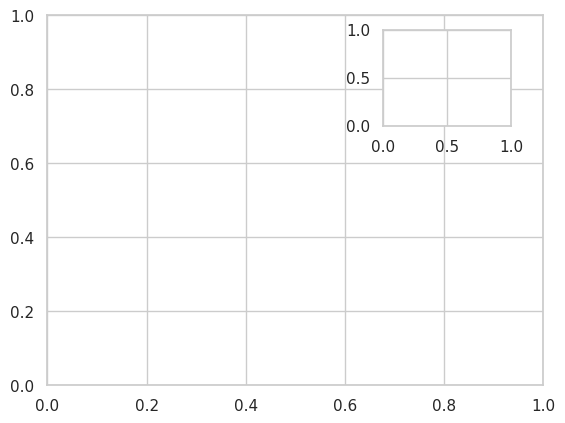

In [33]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

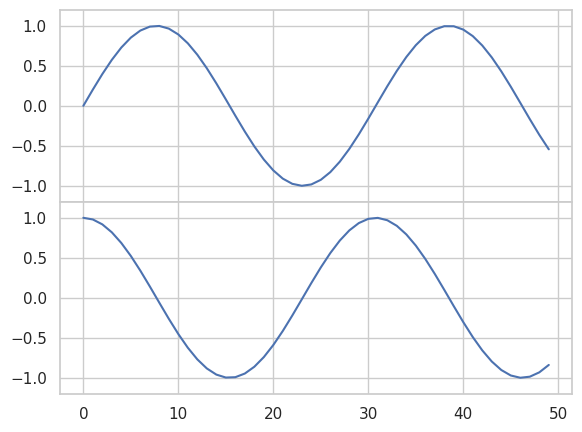

In [34]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

### ``plt.subplot``: Simple Grids of Subplots

Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is ``plt.subplot()``, which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

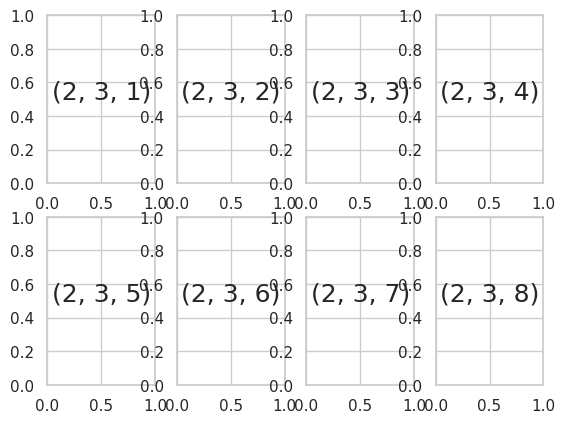

In [35]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')


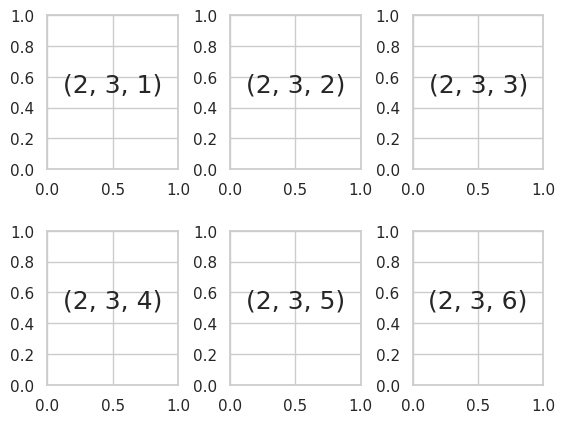

In [36]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

### ``plt.subplots``: The Whole Grid in One Go

The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots.
For this purpose, ``plt.subplots()`` is the easier tool to use (note the ``s`` at the end of ``subplots``). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array.
The arguments are the number of rows and number of columns, along with optional keywords ``sharex`` and ``sharey``, which allow you to specify the relationships between different axes.

Here we'll create a $2 \times 3$ grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

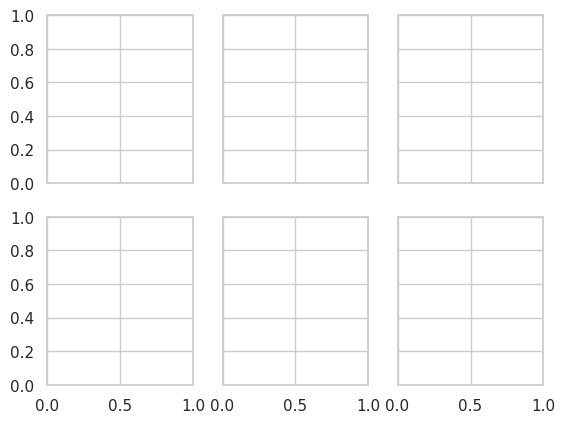

In [37]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying ``sharex`` and ``sharey``, we've automatically removed inner labels on the grid to make the plot cleaner.


The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

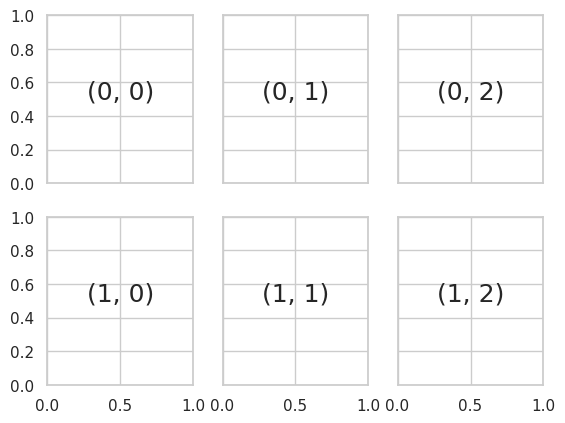

In [38]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

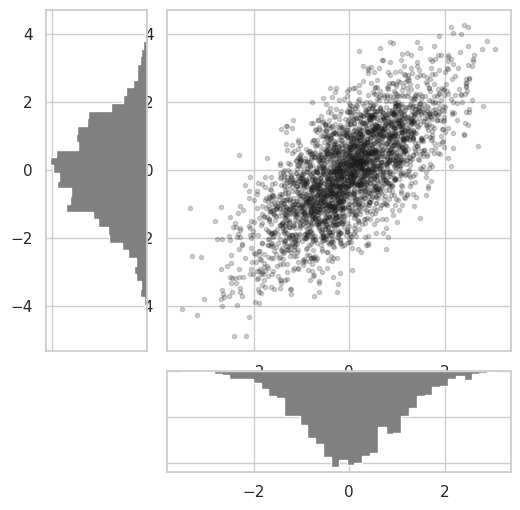

In [39]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()


In [44]:
import matplotlib as mpl
import pandas as pd
import numpy as np

# An example of Complex Plotting
births = pd.read_csv('births.csv')

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(10000 * births.year +
                              100 * births.month +
                              births.day, format='%Y%m%d')
births_by_date = births.pivot_table('births',
                                    [births.index.month, births.index.day])
# Use pd.Timestamp instead of pd.datetime
births_by_date.index = [pd.Timestamp(year=2012, month=month, day=day)
                        for (month, day) in births_by_date.index]

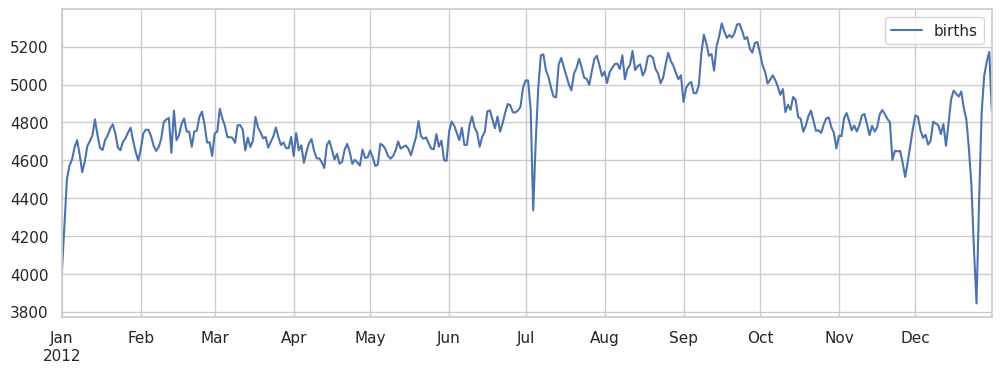

In [45]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);

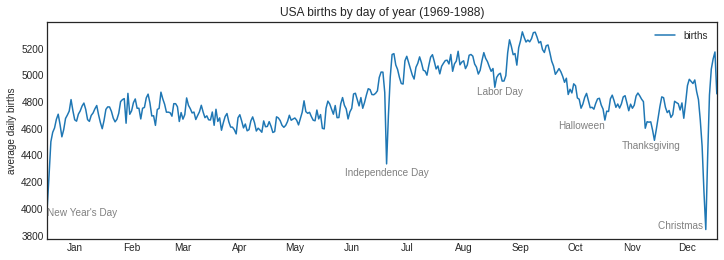

### Boxplot

A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.



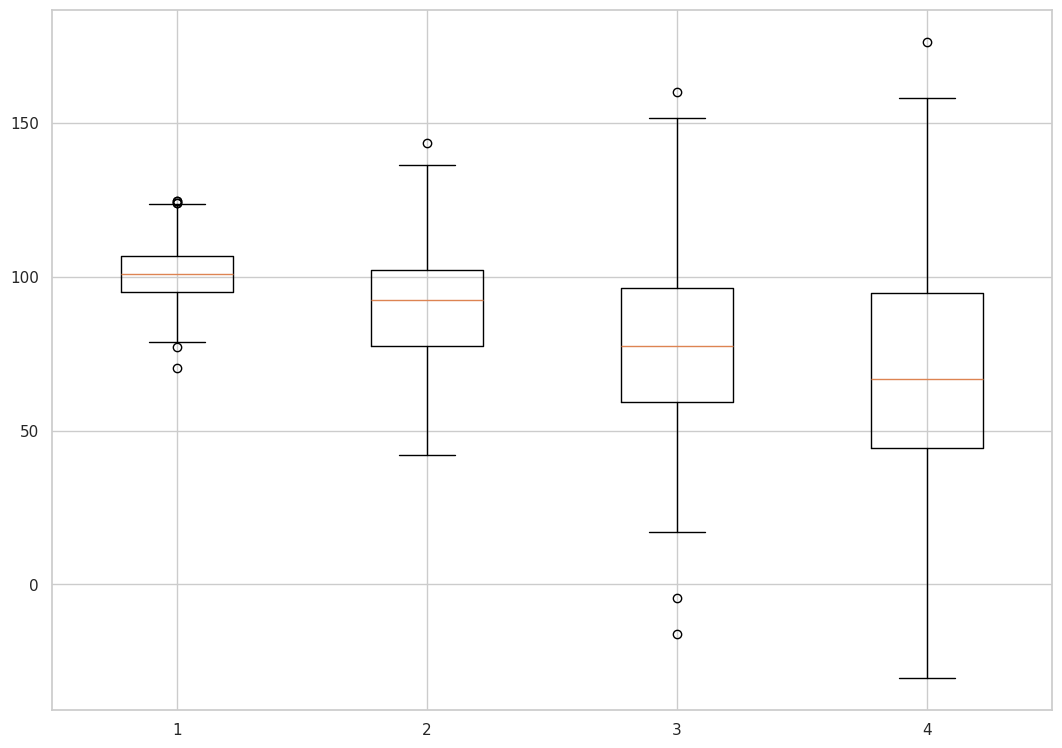

In [46]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()


Questions:

1. What is boxplot ?<br>
A boxplot shows you:
<br>
The center, spread, and skewness of the data
<br>
Presence of outliers
<br>

When to use a boxplot?<br>
To compare distributions across multiple groups

To identify outliers

To summarize data without assuming any specific distribution
<br>

2. What information do we get from a box plot?<br>
A box plot gives you a compact and visual summary of your data’s distribution, and it helps you quickly spot key patterns, outliers, and differences between groups.<br>
What Information Does a Box Plot Provide?
1. Median (Q2) — Central Tendency
The line inside the box shows the median (middle value).

Helps you know where the center of your data lies.

2. Interquartile Range (IQR) — Spread of Middle Data
The box itself spans from Q1 to Q3 (25th to 75th percentile).

This range contains the middle 50% of the data.

Wider box = more variability; narrow box = more consistency.

3. Whiskers — Range of Non-Outlier Data
Whiskers extend from:

Lower whisker: Q1 − 1.5×IQR (minimum)

Upper whisker: Q3 + 1.5×IQR (maximum)

They show the bulk range of the data (excluding outliers).

4. Outliers — Unusual Data Points
Data points beyond the whiskers are plotted as individual dots or stars.

These are potential outliers and may need special attention.

5. Skewness / Symmetry
If the median is not centered in the box, or whiskers are uneven, it tells you the data is skewed.

Median closer to bottom = right-skewed

<br><br>

3. How is minimum and maximum whisker's marked in a box plot <br>
 How Whiskers Are Determined in a Box Plot
The whiskers do not necessarily reach the actual min or max values of the dataset. Instead, they extend to the farthest data points that are not considered outliers.

Q1 = 1st quartile (25th percentile)

Q3 = 3rd quartile (75th percentile)

IQR = Q3 − Q1

Whiskers go to:
Minimum whisker: The smallest data point that is ≥ Q1 − 1.5×IQR

Maximum whisker: The largest data point that is ≤ Q3 + 1.5×IQR
Outliers:
Any data below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is treated as an outlier
Outliers are plotted as individual points (like ● or ✳)

4. How to we identify that some points in data are outliers by viewing the box plot?<br>
Identifying outliers in a box plot is actually one of its main purposes, and it's super visual!

🔍 How to Spot Outliers in a Box Plot
Outliers appear as individual points, usually drawn outside the "whiskers".
They extend to the furthest non-outlier points.

Their range is determined by the formula:

Lower whisker ends at: Q1 − 1.5 × IQR

Upper whisker ends at: Q3 + 1.5 × IQR
<br>
Outliers:

Any point beyond those whisker limits is marked separately.

Usually drawn as:

dots (●),

circles (o),

or stars (*), depending on the library or style.


5. Read a data file from your drive and for all numeric columns plot boxplot.


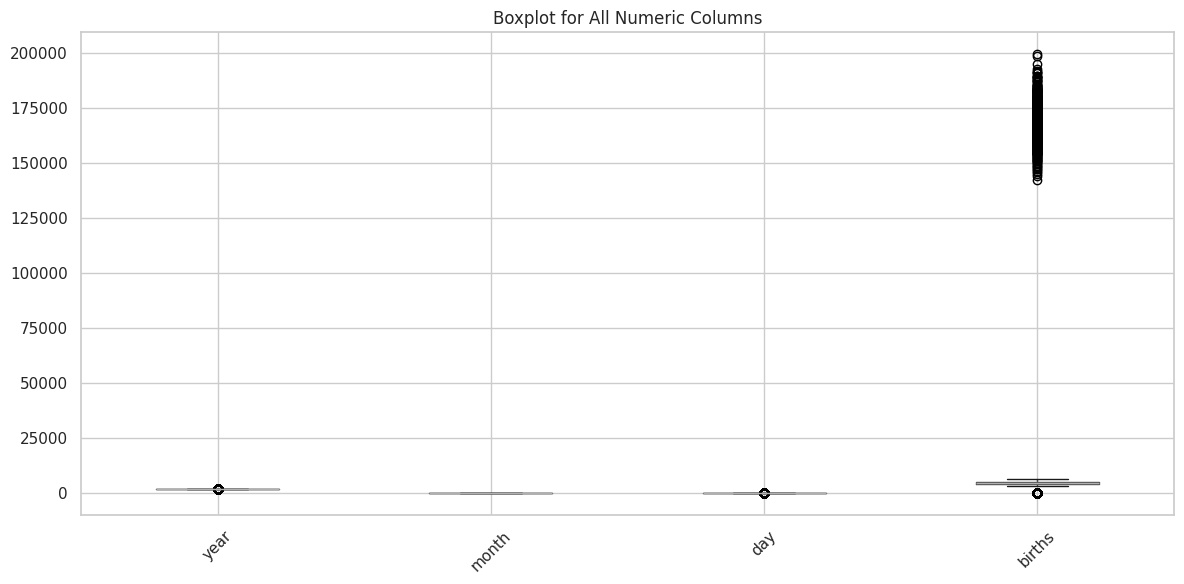

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load your file
# Replace 'your_file.csv' with the actual path or filename
df = pd.read_csv('births.csv')  # or use .xlsx with pd.read_excel()

# Step 2: Select numeric columns
numeric_data = df.select_dtypes(include='number')

# Step 3: Plot boxplots
plt.figure(figsize=(12, 6))
numeric_data.boxplot()
plt.title("Boxplot for All Numeric Columns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Conclusion
Thus we have learned about basics of  Contour plots, Histograms, Box plots.